## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from nltk.stem.porter import PorterStemmer
import nltk
nltk.download('punkt', quiet=True)

True

## Step 2: Load Dataset

In [2]:
movies  = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print('Movies shape :', movies.shape)
print('Credits shape:', credits.shape)

# Merge on title
movies = movies.merge(credits, on='title')
print('After merge  :', movies.shape)
movies.head(2)

Movies shape : (4803, 20)
Credits shape: (4803, 4)
After merge  : (4809, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [3]:
movies['overview']

,overview
0,"In the 22nd century, a paraplegic Marine is di..."
1,"Captain Barbossa, long believed to be dead, ha..."
2,A cryptic message from Bond’s past sends him o...
3,Following the death of District Attorney Harve...
4,"John Carter is a war-weary, former military ca..."
...,...
4804,El Mariachi just wants to play his guitar and ...
4805,A newlywed couple's honeymoon is upended by th...
4806,"""Signed, Sealed, Delivered"" introduces a dedic..."
4807,When ambitious New York attorney Sam is sent t...


## Step 3: Select Columns & Clean

In [4]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
print('Missing values:')
print(movies.isnull().sum())
movies.dropna(inplace=True)
print('Shape after cleaning:', movies.shape)

Missing values:
movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64
Shape after cleaning: (4806, 7)


## Step 4: EDA — Genre Distribution

/tmp/ipykernel_2116/4033945567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genres_df, x='Genre', y='Count', palette='Blues_d')


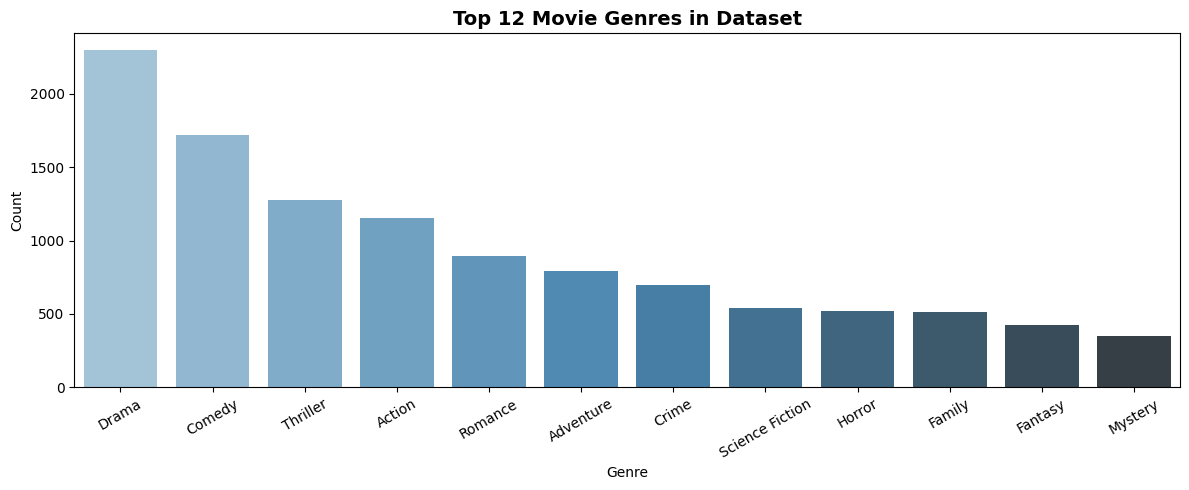

Chart saved!


In [5]:
def extract_names(obj):
    return [i['name'] for i in ast.literal_eval(obj)]

all_genres = [g for sub in movies['genres'].apply(extract_names) for g in sub]
genre_counts = Counter(all_genres).most_common(12)
genres_df = pd.DataFrame(genre_counts, columns=['Genre','Count'])

plt.figure(figsize=(12,5))
sns.barplot(data=genres_df, x='Genre', y='Count', palette='Blues_d')
plt.title('Top 12 Movie Genres in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()
print('Chart saved!')

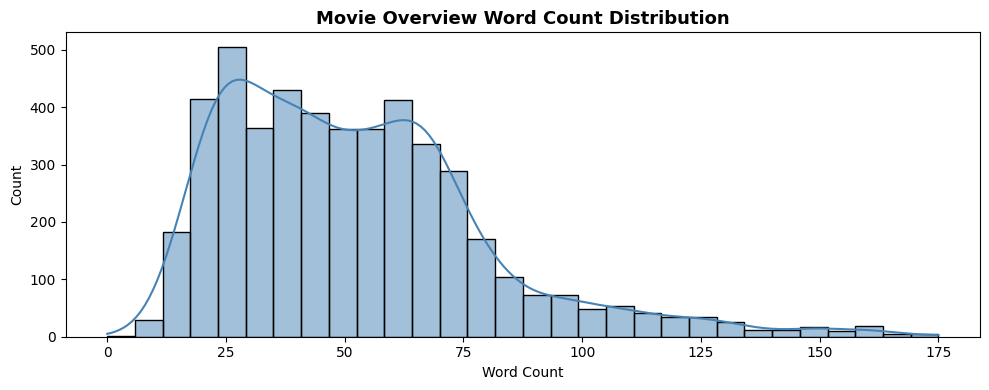

Avg overview length: 52.2 words


In [6]:
movies['overview_length'] = movies['overview'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,4))
sns.histplot(movies['overview_length'], bins=30, color='steelblue', kde=True)
plt.title('Movie Overview Word Count Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.tight_layout()
plt.savefig('overview_length.png', dpi=150)
plt.show()
print(f'Avg overview length: {movies["overview_length"].mean():.1f} words')

## Step 5: Feature Engineering

In [7]:
def convert(obj):
    return [i['name'] for i in ast.literal_eval(obj)]

def get_top3_cast(obj):
    return [i['name'] for i in ast.literal_eval(obj)][:3]

def get_director(obj):
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            return [i['name']]
    return []

movies['genres']   = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast']     = movies['cast'].apply(get_top3_cast)
movies['crew']     = movies['crew'].apply(get_director)
movies['overview'] = movies['overview'].apply(lambda x: x.split())

print('Conversion done!')
print('Sample genres:', movies['genres'].iloc[0])
print('Sample cast  :', movies['cast'].iloc[0])
print('Director     :', movies['crew'].iloc[0])

Conversion done!
Sample genres: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Sample cast  : ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']
Director     : ['James Cameron']


In [8]:
# Remove spaces from names to avoid false matches
def collapse(lst):
    return [i.replace(' ','') for i in lst]

movies['genres']   = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)
movies['cast']     = movies['cast'].apply(collapse)
movies['crew']     = movies['crew'].apply(collapse)

print('Spaces collapsed!')
print('Cast after collapse:', movies['cast'].iloc[0])

Spaces collapsed!
Cast after collapse: ['SamWorthington', 'ZoeSaldana', 'SigourneyWeaver']


In [9]:
# Combine all features into one 'tags' column
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

new_df = movies[['movie_id','title','tags']].copy()
new_df['tags'] = new_df['tags'].apply(lambda x: ' '.join(x).lower())

print('Tags column created!')
print('Sample tags:')
print(new_df.iloc[0]['tags'][:250])
new_df.head(3)

Tags column created!
Sample tags:
in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar space


,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...


## Step 6: Apply Stemming

In [10]:
ps = PorterStemmer()

def stem(text):
    return ' '.join([ps.stem(word) for word in text.split()])

new_df['tags'] = new_df['tags'].apply(stem)
print('Stemming applied!')
print('Sample stemmed tags:')
print(new_df.iloc[0]['tags'][:200])

Stemming applied!
Sample stemmed tags:
in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cul


## Step 7: Vectorization — CountVectorizer

In [11]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

print(f'Vector shape: {vectors.shape}')
print(f'Total features: {len(cv.get_feature_names_out())}')

# Top 20 frequent words
word_freq = vectors.sum(axis=0)
words = cv.get_feature_names_out()
top20 = sorted(zip(words, word_freq), key=lambda x: -x[1])[:20]
print('\nTop 20 words in tags:')
for w, f in top20:
    print(f'  {w:20s} {int(f)}')

Vector shape: (4806, 5000)
Total features: 5000

Top 20 words in tags:
  hi                   4009
  drama                2386
  comedi               1821
  thriller             1316
  action               1260
  romanc               994
  famili               950
  ha                   949
  adventur             928
  life                 852
  crime                829
  new                  721
  world                648
  young                638
  man                  601
  love                 587
  year                 586
  horror               583
  mysteri              583
  becom                547


## Step 8: Cosine Similarity Matrix

Similarity matrix: (4806, 4806)
Total pairs: 23,097,636


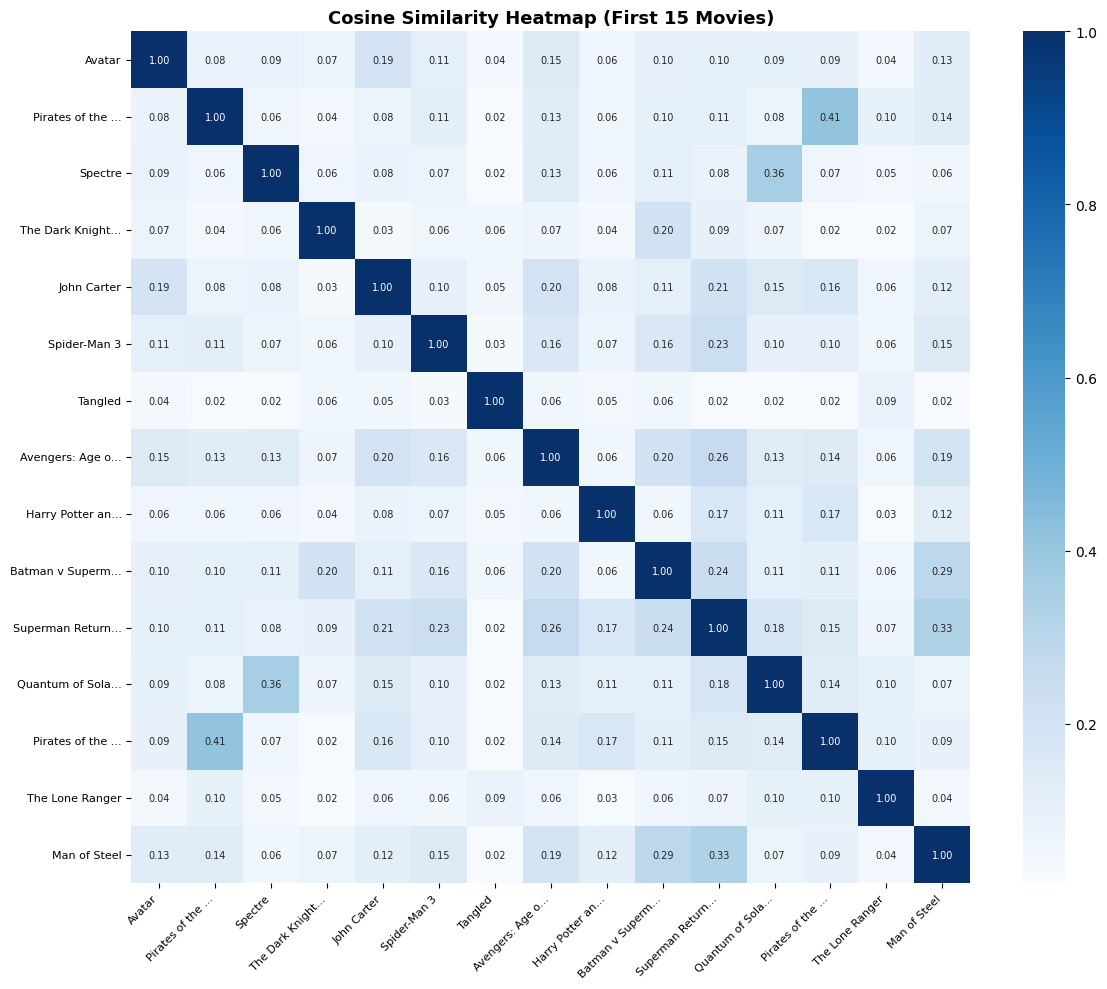

In [15]:
similarity = cosine_similarity(vectors)
print(f'Similarity matrix: {similarity.shape}')
print(f'Total pairs: {similarity.shape[0]*similarity.shape[1]:,}')

# Heatmap for first 15 movies
plt.figure(figsize=(12,10))
subset = similarity[:15,:15]
labels = [t[:15]+'...' if len(t)>15 else t for t in new_df['title'].values[:15]]
sns.heatmap(subset, xticklabels=labels, yticklabels=labels,
            cmap='Blues', annot=True, fmt='.2f', annot_kws={'size':7})
plt.title('Cosine Similarity Heatmap (First 15 Movies)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()

## Step 9: Recommendation Function

In [13]:
def recommend(movie, n=5):
    """
    Recommend top-n similar movies.
    Args:
        movie (str): Title of movie
        n     (int): Number of recommendations
    Returns:
        list of (title, score) tuples
    """
    matches = new_df[new_df['title'].str.lower() == movie.lower()]
    if matches.empty:
        print(f'Movie "{movie}" not found!')
        return []

    idx = matches.index[0]
    distances = similarity[idx]
    sorted_movies = sorted(enumerate(distances), key=lambda x: x[1], reverse=True)[1:n+1]

    print(f'\nMovies similar to "{movie}":')
    print('-' * 48)
    results = []
    for rank, (i, score) in enumerate(sorted_movies, 1):
        title = new_df.iloc[i].title
        print(f'  {rank}. {title:<38} score: {score:.3f}')
        results.append((title, round(score, 3)))
    return results

print('recommend() function ready!')

recommend() function ready!


## Step 10: Test Recommendations


In [16]:
recommend('Avatar')


Movies similar to "Avatar":
------------------------------------------------
  1. Aliens vs Predator: Requiem            score: 0.287
  2. Aliens                                 score: 0.269
  3. Falcon Rising                          score: 0.261
  4. Independence Day                       score: 0.256
  5. Titan A.E.                             score: 0.250


[('Aliens vs Predator: Requiem', np.float64(0.287)),
 ('Aliens', np.float64(0.269)),
 ('Falcon Rising', np.float64(0.261)),
 ('Independence Day', np.float64(0.256)),
 ('Titan A.E.', np.float64(0.25))]

In [17]:
recommend('The Dark Knight')


Movies similar to "The Dark Knight":
------------------------------------------------
  1. The Dark Knight Rises                  score: 0.423
  2. Batman Begins                          score: 0.402
  3. Batman Returns                         score: 0.331
  4. Batman Forever                         score: 0.294
  5. Batman                                 score: 0.277


[('The Dark Knight Rises', np.float64(0.423)),
 ('Batman Begins', np.float64(0.402)),
 ('Batman Returns', np.float64(0.331)),
 ('Batman Forever', np.float64(0.294)),
 ('Batman', np.float64(0.277))]

In [18]:
recommend('Inception')


Movies similar to "Inception":
------------------------------------------------
  1. 12 Rounds                              score: 0.304
  2. RED                                    score: 0.282
  3. Abduction                              score: 0.280
  4. Krrish                                 score: 0.275
  5. The Animal                             score: 0.275


[('12 Rounds', np.float64(0.304)),
 ('RED', np.float64(0.282)),
 ('Abduction', np.float64(0.28)),
 ('Krrish', np.float64(0.275)),
 ('The Animal', np.float64(0.275))]

In [19]:
recommend('The Godfather')


Movies similar to "The Godfather":
------------------------------------------------
  1. Desert Dancer                          score: 0.451
  2. Step Up                                score: 0.385
  3. Take the Lead                          score: 0.378
  4. Footloose                              score: 0.373
  5. Tango                                  score: 0.348


[('Desert Dancer', np.float64(0.451)),
 ('Step Up', np.float64(0.385)),
 ('Take the Lead', np.float64(0.378)),
 ('Footloose', np.float64(0.373)),
 ('Tango', np.float64(0.348))]

In [20]:
recommend('Interstellar', n=10)


Movies similar to "Interstellar":
------------------------------------------------
  1. Guardians of the Galaxy                score: 0.250
  2. Silent Running                         score: 0.245
  3. Space Cowboys                          score: 0.223
  4. The Martian                            score: 0.216
  5. Apollo 13                              score: 0.216
  6. The Right Stuff                        score: 0.215
  7. A.I. Artificial Intelligence           score: 0.212
  8. Space Pirate Captain Harlock           score: 0.210
  9. Ender's Game                           score: 0.207
  10. Zathura: A Space Adventure             score: 0.203


[('Guardians of the Galaxy', np.float64(0.25)),
 ('Silent Running', np.float64(0.245)),
 ('Space Cowboys', np.float64(0.223)),
 ('The Martian', np.float64(0.216)),
 ('Apollo 13', np.float64(0.216)),
 ('The Right Stuff', np.float64(0.215)),
 ('A.I. Artificial Intelligence', np.float64(0.212)),
 ('Space Pirate Captain Harlock', np.float64(0.21)),
 ("Ender's Game", np.float64(0.207)),
 ('Zathura: A Space Adventure', np.float64(0.203))]

## Step 11: Visualization

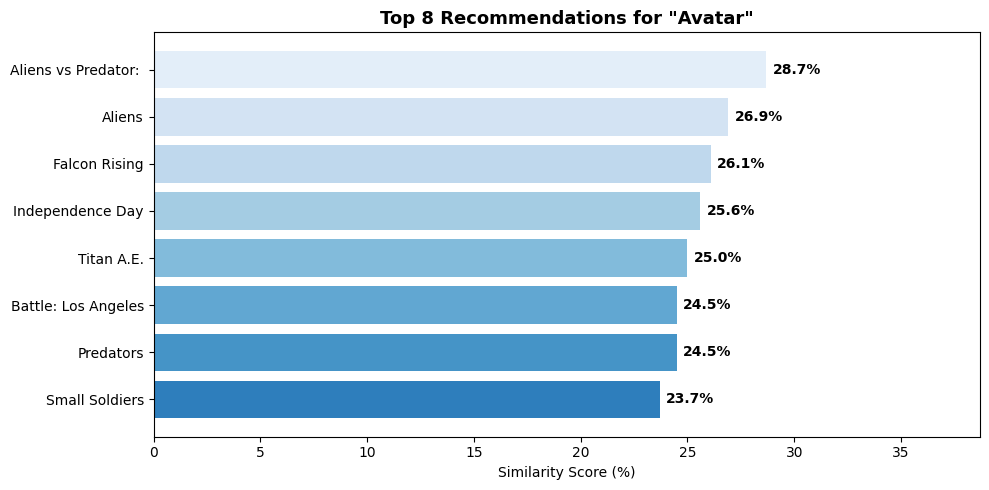

Chart saved as reco_Avatar.png


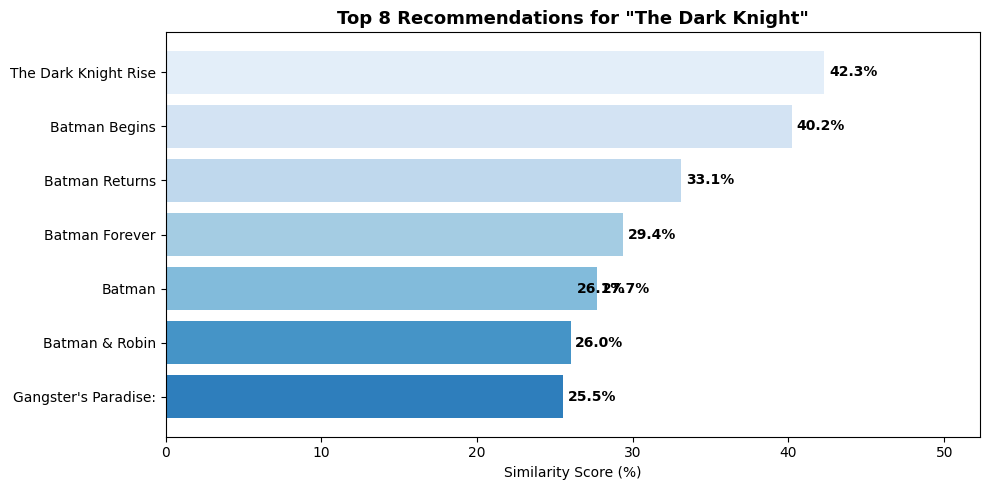

Chart saved as reco_The_Dark_Knight.png


In [21]:
def visualize_recommendations(movie, n=8):
    matches = new_df[new_df['title'].str.lower() == movie.lower()]
    if matches.empty:
        print(f'Movie "{movie}" not found!')
        return
    idx = matches.index[0]
    distances = similarity[idx]
    sorted_movies = sorted(enumerate(distances), key=lambda x: x[1], reverse=True)[1:n+1]
    titles = [new_df.iloc[i].title[:20] for i,_ in sorted_movies]
    scores = [round(s*100,1) for _,s in sorted_movies]
    plt.figure(figsize=(10,5))
    colors = plt.cm.Blues_r(np.linspace(0.3,0.9,len(titles)))
    bars = plt.barh(titles[::-1], scores[::-1], color=colors)
    for bar, score in zip(bars, scores[::-1]):
        plt.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{score}%', va='center', fontsize=10, fontweight='bold')
    plt.title(f'Top {n} Recommendations for "{movie}"', fontsize=13, fontweight='bold')
    plt.xlabel('Similarity Score (%)')
    plt.xlim(0, max(scores)+10)
    plt.tight_layout()
    fname = f'reco_{movie.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Chart saved as {fname}')

visualize_recommendations('Avatar')
visualize_recommendations('The Dark Knight')

## Step 12: Save Model for Streamlit App

In [22]:
pickle.dump(new_df,     open('movies.pkl',     'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))
pickle.dump(cv,         open('vectorizer.pkl', 'wb'))

print('Model saved!')
print('  movies.pkl     — movie dataframe')
print('  similarity.pkl — cosine similarity matrix')
print('  vectorizer.pkl — fitted CountVectorizer')
print()
print('Run Streamlit app with:  streamlit run app.py')

Model saved!
  movies.pkl     — movie dataframe
  similarity.pkl — cosine similarity matrix
  vectorizer.pkl — fitted CountVectorizer

Run Streamlit app with:  streamlit run app.py


## Step 13: Summary

In [23]:
print('='*50)
print('  MOVIE RECOMMENDATION SYSTEM SUMMARY')
print('='*50)
print(f'  Total movies        : {len(new_df)}')
print(f'  Feature vector size : {vectors.shape[1]}')
print(f'  Similarity matrix   : {similarity.shape[0]} x {similarity.shape[1]}')
print(f'  Algorithm           : Cosine Similarity')
print(f'  Vectorizer          : CountVectorizer (5000 features)')
print(f'  Features used       : Overview + Genres + Keywords + Cast + Director')
print('='*50)
print('  Author  : Vraj Patoliya')
print('  College : Gandhinagar University — B.Tech IT')
print('='*50)

  MOVIE RECOMMENDATION SYSTEM SUMMARY
  Total movies        : 4806
  Feature vector size : 5000
  Similarity matrix   : 4806 x 4806
  Algorithm           : Cosine Similarity
  Vectorizer          : CountVectorizer (5000 features)
  Features used       : Overview + Genres + Keywords + Cast + Director
  Author  : Vraj Patoliya
  College : Gandhinagar University — B.Tech IT
